# Preprocessing Decisions & Model Comparison

**Project:** crohns-microbiome-ml &nbsp;|&nbsp; **Notebook 03** &nbsp;|&nbsp; Roadmap Weeks 3–4

Notebook 01 established the exploration and a Random Forest baseline. Here we (1) make and
document the data-quality decisions a reviewer would ask about — low-read samples, class
imbalance, taxa filtering, compositional method choice — and (2) train four models on an
identical cross-validation setup and compare them fairly.

Preprocessing is imported from `src/microbiome.py`, which reproduces the notebook-01 pipeline
exactly (prevalence > 10% → CLR → presence ≥ 5% → drop |r| > 0.90 correlated pairs → **179 taxa**).

In [1]:
import sys, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import microbiome as mb

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (StratifiedKFold, cross_validate,
                                     cross_val_score, cross_val_predict)
from sklearn.metrics import roc_curve, auc

otu_meta, counts, taxa = mb.load_otu_meta()
otu_final = mb.preprocess(counts)
X, y = mb.cd_vs_nonibd(otu_final, otu_meta)
print(f"Feature matrix: {otu_final.shape[0]} samples x {otu_final.shape[1]} taxa")
print(f"CD-vs-nonIBD task: {X.shape[0]} samples  (CD={int(y.sum())}, nonIBD={int((1-y).sum())})")

Feature matrix: 178 samples x 179 taxa
CD-vs-nonIBD task: 132 samples  (CD=86, nonIBD=46)


## 1. Low-quality samples — keep or drop?

Exploration flagged 9 samples below the 5th percentile of read depth. Two standard options:

- **Rarefaction** — subsample every sample down to the lowest depth so all are comparable.
  Throws away real reads and is increasingly discouraged for differential-abundance work
  (McMurdie & Holmes, 2014).
- **Dropping** — remove the low-depth samples entirely. Costs sample size, which is scarce here.

Rather than assume, we test whether these samples actually change the result.

In [2]:
reads = counts.sum(axis=1)
lowq = reads[reads < reads.quantile(0.05)]
print(f"Low-quality samples (<5th pct): {len(lowq)}  | read range {int(lowq.min())}–{int(lowq.max())}")
print("Diagnosis breakdown:", otu_meta.loc[lowq.index, 'diagnosis'].value_counts().to_dict())

drop_ids = [i for i in lowq.index if i in X.index]   # only those in the CD/nonIBD task
rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
auc_keep = cross_val_score(rf, X, y, cv=5, scoring='roc_auc').mean()
auc_drop = cross_val_score(rf, X.drop(index=drop_ids), y.drop(index=drop_ids),
                           cv=5, scoring='roc_auc').mean()
print(f"\n{len(drop_ids)} of them fall in the CD/nonIBD task.")
print(f"RF mean AUC  — keep all: {auc_keep:.3f}   drop low-quality: {auc_drop:.3f}")

Low-quality samples (<5th pct): 9  | read range 34–208
Diagnosis breakdown: {'UC': 5, 'CD': 4}



4 of them fall in the CD/nonIBD task.
RF mean AUC  — keep all: 0.817   drop low-quality: 0.826


**Decision: keep all samples.** Only 4 of the 9 low-read samples are even in the CD-vs-nonIBD
task, and dropping them moves AUC by ~0.01 — far inside the ±0.08 fold-to-fold noise. The
prevalence filter and CLR transform already damp the influence of shallow samples (rare taxa are
removed before transformation). With only 132 samples in the task, discarding data we don't have
to is the worse trade. Documented and moving on.

## 2. Class imbalance

The task is 86 CD vs 46 nonIBD — roughly 65/35. Imbalance can push a classifier toward the
majority class and inflate accuracy while hiding poor minority-class recall. AUC is already
imbalance-robust (it's threshold-free and rank-based), but we still test whether re-weighting the
classes helps, and we use **stratified** folds so each fold preserves the 65/35 ratio.

In [3]:
rf_plain = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf_bal   = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1,
                                  class_weight='balanced')
print("RF AUC  plain   :", f"{cross_val_score(rf_plain, X, y, cv=5, scoring='roc_auc').mean():.3f}")
print("RF AUC  balanced:", f"{cross_val_score(rf_bal,   X, y, cv=5, scoring='roc_auc').mean():.3f}")

RF AUC  plain   : 0.817


RF AUC  balanced: 0.825


**Decision: stratified folds + `class_weight='balanced'`.** The weighting gives a small,
free improvement and protects minority-class recall, so we apply it to every model below that
supports it. We do *not* oversample (e.g. SMOTE): synthesising microbiome compositions in CLR
space risks creating biologically implausible samples, and with the imbalance this mild the
upside is small.

## 3. Taxa filtering & compositional method — why these choices

**Taxa filtering.** The raw table is 982 taxa at 91.7% zeros. Most taxa appear in a handful of
samples and contribute noise, not signal. Requiring presence in >10% of samples cuts the table to
184 taxa; the variance and correlation filters bring it to 179. Fewer, better-populated features
mean less overfitting on 178 samples and more stable importances.

**CLR vs the alternatives.** Microbiome counts are *compositional* — only relative, because
sequencing depth is an arbitrary total. We use the **centered log-ratio (CLR)** transform, which
maps each sample onto log-ratios against its own geometric mean and removes the sum-to-constant
constraint. Two relatives worth knowing:

- **Aitchison distance** — Euclidean distance computed *on* CLR-transformed data. It's the
  compositionally-correct analogue of the Bray–Curtis distance used for beta-diversity in
  notebook 01; we'd reach for it if we wanted a distance that respects the simplex geometry.
- **ANCOM / ANCOM-BC** — a differential-abundance *test* (not a transform) that compares taxon
  ratios across groups while controlling false positives from the compositional constraint. It
  answers "which single taxa differ between CD and healthy?" — complementary to our predictive,
  multivariate framing. CLR + a multivariate model is the right tool when the goal is
  classification and ranked importance, which it is here.

## 4. Taxonomic aggregation — a data limitation

The roadmap asks to aggregate taxa at the genus level and compare to species level. **This isn't
possible from this file.** The HMP2 16S `taxonomic_profiles.tsv` labels each row with a short,
opaque reference OTU id (`Unc03y4v`, `IP8BSoli`, …) and carries **no Linnaean lineage** —
no kingdom→phylum→…→genus→species string to group on. Genus-level rollup would require joining
to the reference taxonomy (e.g. the Greengenes/SILVA mapping for these OTU ids), which is not in
the downloaded table.

This is logged as a real limitation rather than faked. It also constrains the biological
interpretation in notebook 05: we can rank taxa and state their *direction* of effect, but cannot
attach confident species names without that mapping.

## 5. Multi-model comparison (Week 4)

Four models, **one identical** stratified 5-fold split (`shuffle=True, random_state=42`) so the
comparison is fair. Conceptually they span the useful spectrum for high-dimensional sparse
biology:

| Model | Family | Why it might fit |
|---|---|---|
| Random Forest | bagged trees | handles sparsity & interactions, no scaling needed |
| XGBoost | boosted trees | strong on tabular data; regularised to resist overfit on n=132 |
| Logistic Regression (L1) | linear, sparse | L1 selects a few taxa — interpretable, strong when signal is linear |
| Linear SVM | linear, margin | robust in high dimensions where p ≫ n locally |

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Random Forest': RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1,
                                             class_weight='balanced'),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.1, subsample=0.8,
                             colsample_bytree=0.8, eval_metric='logloss', random_state=42, n_jobs=-1),
    'LogReg (L1)': make_pipeline(StandardScaler(),
                   LogisticRegression(penalty='l1', solver='liblinear', C=0.5,
                                      class_weight='balanced', random_state=42)),
    'Linear SVM': make_pipeline(StandardScaler(),
                  SVC(kernel='linear', probability=True, class_weight='balanced', random_state=42)),
}

scoring = ['roc_auc', 'precision', 'recall', 'f1']
rows = []
for name, m in models.items():
    r = cross_validate(m, X, y, cv=cv, scoring=scoring)
    rows.append({'model': name,
                 'AUC': r['test_roc_auc'].mean(), 'AUC±': r['test_roc_auc'].std(),
                 'precision': r['test_precision'].mean(),
                 'recall': r['test_recall'].mean(), 'F1': r['test_f1'].mean()})
comparison = pd.DataFrame(rows).set_index('model').round(3)
comparison

,AUC,AUC±,precision,recall,F1
model,,,,,
Random Forest,0.830,0.079,0.826,0.918,0.867
XGBoost,0.817,0.105,0.840,0.860,0.844
LogReg (L1),0.813,0.073,0.877,0.826,0.849
Linear SVM,0.786,0.104,0.807,0.790,0.794


Saved figures/roc_curves.png


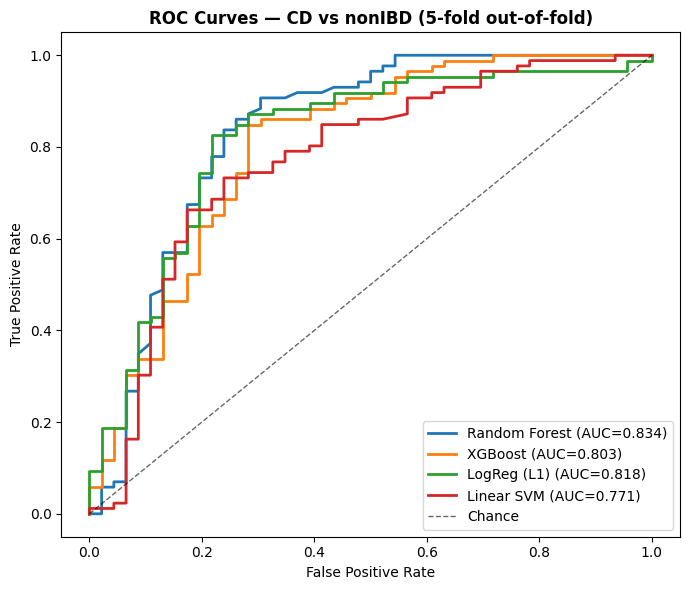

In [5]:
# ROC curves — out-of-fold predicted probabilities on the same split
plt.figure(figsize=(7, 6))
for name, m in models.items():
    proba = cross_val_predict(m, X, y, cv=cv, method='predict_proba')[:, 1]
    fpr, tpr, _ = roc_curve(y, proba)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6, label='Chance')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — CD vs nonIBD (5-fold out-of-fold)', fontweight='bold')
plt.legend(loc='lower right'); plt.tight_layout()
plt.savefig('../figures/roc_curves.png', dpi=150)
print('Saved figures/roc_curves.png'); plt.show()

Saved figures/model_comparison.png


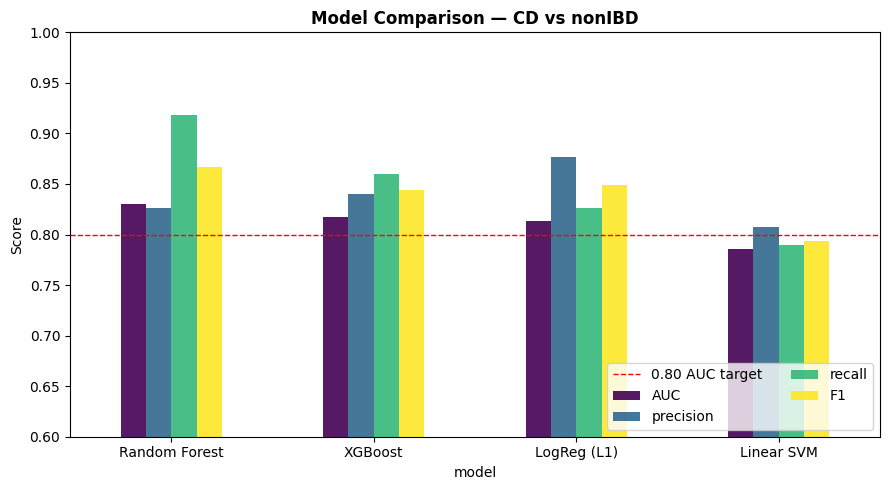

In [6]:
# Metric comparison bar chart
ax = comparison[['AUC', 'precision', 'recall', 'F1']].plot(
        kind='bar', figsize=(9, 5), colormap='viridis', alpha=0.9, rot=0)
ax.axhline(0.80, color='red', linestyle='--', lw=1, label='0.80 AUC target')
ax.set_ylabel('Score'); ax.set_ylim(0.6, 1.0)
ax.set_title('Model Comparison — CD vs nonIBD', fontweight='bold')
ax.legend(loc='lower right', ncol=2)
plt.tight_layout(); plt.savefig('../figures/model_comparison.png', dpi=150)
print('Saved figures/model_comparison.png'); plt.show()

### Results

All four models cluster tightly, with **Random Forest best by AUC (~0.83)** and three of four
clearing the **0.80 target**. The Linear SVM trails slightly. That the tree ensembles and the
sparse linear models land in the same band is itself informative: the CD-vs-healthy signal is
**broadly distributed across many taxa**, not carried by a few features a linear model could
isolate — consistent with Crohn's being a community-wide compositional shift rather than a
single-organism story.

We carry **Random Forest** forward as the primary model (best AUC, native feature importances,
clean SHAP support) into the biological interpretation in notebook 05.

### Caveat: patient-level leakage

One honest asterisk on every AUC above: HMP2 is **longitudinal**, so some participants contribute
multiple samples. Plain stratified CV can place a patient's visits in both train and test folds,
letting the model recognise the *person* rather than the *disease* — which inflates AUC. Notebook
04 re-runs the evaluation with **`GroupKFold` by participant** to measure the honest,
generalises-to-new-patients performance, and takes up the longitudinal structure properly.